In [1]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F


from draughts import Color, AlphaBetaEngine, HubEngine
from draughts.boards.standard import Board
from draughts.benchmark import Benchmark
import tqdm


In [2]:
# check if gpu is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.version.cuda)    
print(f"Using device: {device}")
print(f"Number of available devices: {torch.cuda.device_count()}")
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"Device {i}: {torch.cuda.get_device_name(i)}")

13.0
Using device: cuda
Number of available devices: 1
Device 0: NVIDIA GeForce RTX 5060 Ti


In [3]:
import pickle 
# data is in ./data.pkl
data = pickle.load(open("./data.pkl", "rb"))
data2 = pickle.load(open("./data2.pkl", "rb"))
data = [data[0] + data2[0], data[1] + data2[1]]
print(len(data))
print(len(data[0]))

2
2001508


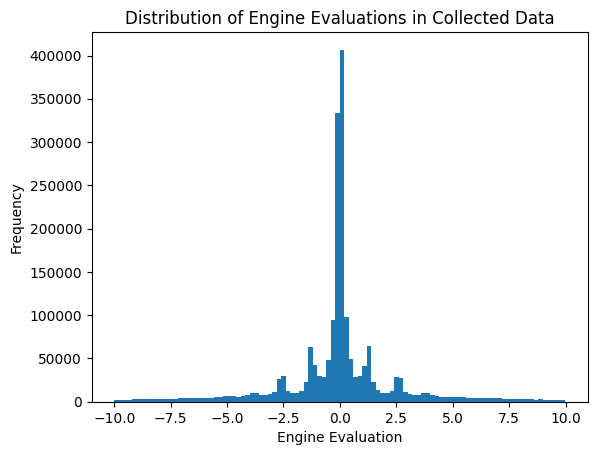

In [4]:
import matplotlib.pyplot as plt

# Use the first element of data, which is the list of samples
samples = data[0]
sample_weights = data[1]
# Remove outliers for better visualization
filtered = [d for d in samples if -10 < d[2] < 10]
plt.hist([d[2] for d in filtered], bins=100)
plt.xlabel("Engine Evaluation")
plt.ylabel("Frequency")
plt.title("Distribution of Engine Evaluations in Collected Data")
plt.show()


In [5]:
def train_epoch(net, opt, data, sample_weights=None, batch_size=256):
    """
    Joint policy + value training with weighted sampling.
    """
    device = next(net.parameters()).device
    
    states = torch.from_numpy(np.stack([d[0] for d in data])).to(device, dtype=torch.float32)
    actions = torch.tensor([d[1] for d in data], device=device, dtype=torch.long)
    evals = torch.tensor([d[2] for d in data], device=device, dtype=torch.float32)
    
    value_targets = torch.tanh(evals / 5.0)
    
    dataset_size = len(data)
    
    if sample_weights is not None:
        weights = torch.tensor(sample_weights, device=device, dtype=torch.float32)
        weights = weights / weights.sum()
        indices = torch.multinomial(weights, dataset_size, replacement=True)
    else:
        indices = torch.randperm(dataset_size, device=device)
    
    total_loss, policy_loss_sum, value_loss_sum = 0, 0, 0
    correct, total = 0, 0
    top5_correct = 0
    
    for i in range(0, dataset_size, batch_size):
        idx = indices[i:i+batch_size]
        b_states = states[idx]
        b_actions = actions[idx]
        b_values = value_targets[idx]
        
        # Data augmentation: random horizontal flip
        if net.training:
            flip_mask = torch.rand(len(idx), device=device) < 0.5
            if flip_mask.any():
                flipped = b_states[flip_mask].view(-1, 4, 10, 5).flip(dims=[3]).view(-1, 4, 50)
                b_states[flip_mask] = flipped
                orig_actions = b_actions[flip_mask]
                from_sq = orig_actions // 50
                to_sq = orig_actions % 50
                from_row, from_col = from_sq // 5, from_sq % 5
                to_row, to_col = to_sq // 5, to_sq % 5
                new_from = from_row * 5 + (4 - from_col)
                new_to = to_row * 5 + (4 - to_col)
                b_actions[flip_mask] = new_from * 50 + new_to
        
        policy_logits, value_pred = net.forward_both(b_states)
        
        # Label smoothing for regularization
        policy_loss = F.cross_entropy(policy_logits, b_actions, label_smoothing=0.15)
        value_loss = F.mse_loss(value_pred.squeeze(), b_values)
        
        # Combined loss
        loss = policy_loss + 0.5 * value_loss
        
        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(net.parameters(), 1.0)
        opt.step()
        
        total_loss += loss.item() * len(idx)
        policy_loss_sum += policy_loss.item() * len(idx)
        value_loss_sum += value_loss.item() * len(idx)
        
        correct += (policy_logits.argmax(1) == b_actions).sum().item()
        top5 = policy_logits.topk(5, dim=1).indices
        top5_correct += (top5 == b_actions.unsqueeze(1)).any(1).sum().item()
        total += len(idx)
    
    return (total_loss / total, policy_loss_sum / total, value_loss_sum / total,
            correct / total * 100, top5_correct / total * 100)

In [6]:
class NNEngine:
    """Wrap neural net as Engine for benchmarking."""
    name = "NeuralNet"
    depth_limit = time_limit = None
    
    def __init__(self, net): self.net = net
    
    def get_best_move(self, board):
        device = next(self.net.parameters()).device
        with torch.no_grad():
            # Move input tensor and mask to device
            input_tensor = torch.from_numpy(board.to_tensor()).unsqueeze(0).to(device, dtype=torch.float32)
            logits = self.net(input_tensor)
            mask = torch.from_numpy(board.legal_moves_mask()).to(device)
            logits[0][~mask] = -1e9
            return board.index_to_move(logits[0].argmax().item())


In [7]:
class ConvBlock(nn.Module):
    """Conv block with batch norm and residual connection."""
    def __init__(self, channels, dropout=0.1):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        self.dropout = nn.Dropout2d(dropout)  # Spatial dropout
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)
    
    def forward(self, x):
        residual = x
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.dropout(x)
        x = self.bn2(self.conv2(x))
        return F.relu(x + residual)

class PolicyValueNet(nn.Module):
    """
    CNN-based network with stronger regularization.
    """
    def __init__(self, sq=50, channels=96, n_blocks=6, dropout=0.4):
        super().__init__()
        self.sq = sq
        
        # Input conv
        self.input_conv = nn.Sequential(
            nn.Conv2d(4, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU(),
            nn.Dropout2d(0.1)
        )
        
        # Residual tower (fewer blocks, more dropout)
        self.res_tower = nn.Sequential(*[ConvBlock(channels, dropout=0.15) for _ in range(n_blocks)])
        
        # Policy head with more dropout
        self.policy_conv = nn.Sequential(
            nn.Conv2d(channels, 32, 1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Flatten(),
            nn.Dropout(dropout)
        )
        self.policy_fc = nn.Linear(32 * 10 * 5, sq * sq)
        
        # Value head  
        self.value_conv = nn.Sequential(
            nn.Conv2d(channels, 4, 1),
            nn.BatchNorm2d(4),
            nn.ReLU(),
            nn.Flatten()
        )
        self.value_fc = nn.Sequential(
            nn.Linear(4 * 10 * 5, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
            nn.Tanh()
        )
    
    def _reshape_input(self, x):
        if x.dim() == 2:
            x = x.view(-1, 4, self.sq)
        return x.view(-1, 4, 10, 5)
    
    def forward(self, x):
        x = self._reshape_input(x)
        x = self.input_conv(x)
        x = self.res_tower(x)
        p = self.policy_conv(x)
        return self.policy_fc(p)
    
    def forward_both(self, x):
        x = self._reshape_input(x)
        x = self.input_conv(x)
        x = self.res_tower(x)
        
        p = self.policy_conv(x)
        policy = self.policy_fc(p)
        
        v = self.value_conv(x)
        value = self.value_fc(v)
        
        return policy, value

PolicyNet = PolicyValueNet

In [8]:
def rl_train_step(net, opt, engine, n_games=20, temp=0.5):
    """
    Improved RL training with:
    - Better reward scaling
    - Advantage estimation (baseline subtraction)
    - Entropy bonus for exploration
    """
    device = next(net.parameters()).device
    net.eval()
    
    active_games = [{"board": Board(), "data": [], "rewards": []} for _ in range(n_games)]
    completed_data = []
    game_outcomes = []  # Track W/L/D for diagnostics
    
    while active_games:
        states_np = np.stack([g["board"].to_tensor() for g in active_games])
        states_tensor = torch.from_numpy(states_np).to(device, dtype=torch.float32)
        
        with torch.no_grad():
            logits_batch = net(states_tensor)
            
        still_active = []
        for i, game in enumerate(active_games):
            board = game["board"]
            logits = logits_batch[i]
            
            mask = torch.from_numpy(board.legal_moves_mask()).to(device)
            logits[~mask] = -1e9
            
            # Sample with temperature
            probs = F.softmax(logits / temp, dim=0)
            action = torch.multinomial(probs, 1).item()
            log_prob = torch.log(probs[action]).item()
            
            # Immediate reward: eval delta (scaled better)
            ev_before = engine.evaluate(board)
            board.push(board.index_to_move(action))
            
            if board.game_over:
                # Terminal reward based on game outcome
                if board.result == "1-0":
                    terminal_reward = 1.0 if game.get("net_color", Color.WHITE) == Color.WHITE else -1.0
                elif board.result == "0-1":
                    terminal_reward = -1.0 if game.get("net_color", Color.WHITE) == Color.WHITE else 1.0
                else:
                    terminal_reward = 0.0
                ev_after = 0
            else:
                ev_after = -engine.evaluate(board)
                terminal_reward = 0.0
            
            # Combine immediate and terminal rewards with better scaling
            step_reward = (ev_after - ev_before) / 50.0 + terminal_reward
            
            game["data"].append((states_np[i], action, log_prob))
            game["rewards"].append(step_reward)
            
            if not board.game_over:
                still_active.append(game)
            else:
                # Compute returns with discount
                gamma = 0.99
                returns = []
                G = 0
                for r in reversed(game["rewards"]):
                    G = r + gamma * G
                    returns.insert(0, G)
                
                for (state, action, log_p), ret in zip(game["data"], returns):
                    completed_data.append((state, action, log_p, ret))
                
                game_outcomes.append(terminal_reward)
        
        active_games = still_active

    if not completed_data:
        net.train()
        return 0.0, 0.0, 0.0
    
    net.train()
    
    # Prepare tensors
    states = torch.from_numpy(np.stack([d[0] for d in completed_data])).to(device, dtype=torch.float32)
    actions = torch.tensor([d[1] for d in completed_data], device=device, dtype=torch.long)
    old_log_probs = torch.tensor([d[2] for d in completed_data], device=device, dtype=torch.float32)
    returns = torch.tensor([d[3] for d in completed_data], device=device, dtype=torch.float32)
    
    avg_return = returns.mean().item()
    
    # Normalize returns (advantage estimation with baseline)
    returns = (returns - returns.mean()) / (returns.std() + 1e-8)
    
    # PPO-style clipped objective (simplified)
    logits = net(states)
    log_probs = F.log_softmax(logits, dim=1).gather(1, actions.unsqueeze(1)).squeeze(1)
    
    # Importance sampling ratio
    ratio = torch.exp(log_probs - old_log_probs)
    clipped_ratio = torch.clamp(ratio, 0.8, 1.2)
    
    # Policy loss with clipping
    policy_loss = -torch.min(ratio * returns, clipped_ratio * returns).mean()
    
    # Entropy bonus (encourages exploration)
    probs = F.softmax(logits, dim=1)
    entropy = -(probs * F.log_softmax(logits, dim=1)).sum(1).mean()
    
    loss = policy_loss - 0.02 * entropy
    
    opt.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(net.parameters(), 0.5)
    opt.step()
    
    avg_game_len = len(completed_data) / max(len(game_outcomes), 1)
    return loss.item(), avg_game_len, avg_return

In [9]:
@torch.no_grad()
def eval_vs(net, opponent, n=100, random_openings=True):
    """Evaluate net vs opponent. random_openings prevents deterministic loops."""
    device = next(net.parameters()).device
    net.eval()
    
    active_games = []
    for i in range(n):
        board = Board()
        if random_openings:
            # Randomize start to ensure game variety
            for _ in range(random.randint(0, 4)):
                moves = list(board.legal_moves)
                if not moves: break
                board.push(random.choice(moves))
        
        active_games.append({
            "board": board,
            "net_is_white": (i % 2 == 0) # Net plays White in even games
        })
    
    results = {"w": 0, "l": 0, "d": 0}
    
    while active_games:
        net_turn_games = []
        opp_turn_games = []
        
        for game in active_games:
            is_white_turn = (game["board"].turn == Color.WHITE)
            if is_white_turn == game["net_is_white"]:
                net_turn_games.append(game)
            else:
                opp_turn_games.append(game)
        
        if net_turn_games:
            states = torch.from_numpy(np.stack([g["board"].to_tensor() for g in net_turn_games])).to(device, dtype=torch.float32)
            logits_batch = net(states)
            
            for i, game in enumerate(net_turn_games):
                board = game["board"]
                logits = logits_batch[i]
                mask = torch.from_numpy(board.legal_moves_mask()).to(device)
                logits[~mask] = -1e9
                move_idx = logits.argmax().item()
                board.push(board.index_to_move(move_idx))
                
        for game in opp_turn_games:
            board = game["board"]
            move = opponent.get_best_move(board)
            if isinstance(move, tuple): move = move[0]
            board.push(move)
            
        next_active = []
        for game in active_games:
            board = game["board"]
            if board.game_over:
                won = False
                lost = False
                # Determine win/loss from Net's perspective
                if board.result == "1-0": # White Wins
                    won = game["net_is_white"]
                    lost = not game["net_is_white"]
                elif board.result == "0-1": # Black Wins
                    won = not game["net_is_white"]
                    lost = game["net_is_white"]
                
                if won: results["w"] += 1
                elif lost: results["l"] += 1
                else: results["d"] += 1
            else:
                next_active.append(game)
        
        active_games = next_active
    
    net.train()
    return results["w"], results["l"], results["d"]

In [ ]:
engine = AlphaBetaEngine(depth_limit=2)

# Smaller network with more regularization
net = PolicyValueNet(channels=96, n_blocks=6, dropout=0.4).to(device)
print(f"Model parameters: {sum(p.numel() for p in net.parameters()):,}")

best_wr, best_state = 0, None
patience_counter = 0
max_patience = 25  # Increased patience

# Split data AND weights together
combined = list(zip(samples, sample_weights))
random.shuffle(combined)
split_idx = int(len(combined) * 0.9)
train_combined, val_combined = combined[:split_idx], combined[split_idx:]
train_data = [c[0] for c in train_combined]
train_weights = [c[1] for c in train_combined]
val_data = [c[0] for c in val_combined]

print(f"Training samples: {len(train_data)}, Validation samples: {len(val_data)}")

def validate(net, v_data):
    if not v_data: return 0.0, 0.0
    net.eval()
    states = torch.from_numpy(np.stack([d[0] for d in v_data])).to(device, dtype=torch.float32)
    actions = torch.tensor([d[1] for d in v_data], device=device, dtype=torch.long)
    with torch.no_grad():
        logits = net(states)
        top1 = (logits.argmax(1) == actions).float().mean().item() * 100
        top5 = (logits.topk(5, dim=1).indices == actions.unsqueeze(1)).any(1).float().mean().item() * 100
    net.train()
    return top1, top5

# Slightly lower LR, same weight decay
opt = optim.AdamW(net.parameters(), lr=8e-4, weight_decay=5e-4)

# Smoother decay without harsh restarts - single cosine over all epochs
n_epochs = 160
sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs, eta_min=1e-5)

print(f"\n{'Ep':>3} | {'Loss':>6} | {'P_L':>5} | {'V_L':>5} | {'Tr@1':>5} | {'Tr@5':>5} | {'Va@1':>5} | {'Va@5':>5} | {'W/L/D':>10} | {'WR':>3}")
print("-" * 90)

best_val_top5 = 0
for ep in range(1, n_epochs + 1):
    # Pass weights for weighted sampling
    loss, p_loss, v_loss, tr_top1, tr_top5 = train_epoch(net, opt, train_data, train_weights)
    va_top1, va_top5 = validate(net, val_data)
    sched.step()
    
    if va_top5 > best_val_top5:
        best_val_top5 = va_top5
        patience_counter = 0
    else:
        patience_counter += 1
    
    if ep % 5 == 0:
        ew, el, ed = eval_vs(net, engine, n=100, random_openings=True)
        wr = ew
        if wr > best_wr:
            best_wr = wr
            best_state = {k: v.clone() for k, v in net.state_dict().items()}
            net.load_state_dict(best_state)
            torch.save(best_state, "best_model2.pt")
        marker = "*" if wr == best_wr and wr > 0 else ""
        print(f"{ep:3d} | {loss:6.3f} | {p_loss:5.3f} | {v_loss:5.3f} | {tr_top1:5.1f} | {tr_top5:5.1f} | {va_top1:5.1f} | {va_top5:5.1f} | {ew:3d}/{el:3d}/{ed:3d} | {wr:2d}{marker}")
    else:
        print(f"{ep:3d} | {loss:6.3f} | {p_loss:5.3f} | {v_loss:5.3f} | {tr_top1:5.1f} | {tr_top5:5.1f} | {va_top1:5.1f} | {va_top5:5.1f} | {'-':^10} | {'-':^3}")
    
    if patience_counter >= max_patience and ep > 40:
        print(f"\nEarly stopping at epoch {ep}")
        break

# save checkpoint 
if best_state:
    net.load_state_dict(best_state)
    torch.save(best_state, "best_model2.pt")
    print(f"\nSaved best model to best_model.pt (WR: {best_wr}%)")

Model parameters: 5,021,521
Training samples: 1801357, Validation samples: 200151

 Ep |   Loss |   P_L |   V_L |  Tr@1 |  Tr@5 |  Va@1 |  Va@5 |      W/L/D |  WR
------------------------------------------------------------------------------------------
  1 |  3.698 | 3.677 | 0.042 |  25.4 |  70.7 |  31.5 |  79.2 |     -      |  - 
  2 |  3.414 | 3.400 | 0.029 |  31.3 |  78.8 |  34.9 |  82.8 |     -      |  - 
  3 |  3.336 | 3.323 | 0.027 |  33.5 |  81.3 |  36.1 |  83.9 |     -      |  - 
  4 |  3.291 | 3.278 | 0.026 |  34.8 |  82.6 |  37.2 |  84.7 |     -      |  - 
  5 |  3.260 | 3.247 | 0.025 |  35.8 |  83.5 |  38.0 |  85.6 |  26/ 59/ 15 | 26*
  6 |  3.235 | 3.223 | 0.024 |  36.5 |  84.2 |  38.8 |  86.2 |     -      |  - 
  7 |  3.214 | 3.203 | 0.023 |  37.2 |  84.7 |  39.3 |  86.6 |     -      |  - 
  8 |  3.199 | 3.188 | 0.023 |  37.7 |  85.2 |  39.8 |  86.9 |     -      |  - 
  9 |  3.184 | 3.173 | 0.022 |  38.1 |  85.5 |  40.1 |  87.1 |     -      |  - 
 10 |  3.173 | 3.162 | 0.

In [ ]:
# trochę poprawia taktykę
# trochę psuje policy z supervised
# uczy się „jak nie przegrać za szybko”
# nie buduje siły gry


# # Phase 2: RL Fine-tuning
# print("\n" + "=" * 90)
# print("Phase 2: RL Fine-tuning")
# print("=" * 90)

# if best_state:
#     net.load_state_dict(best_state)
#     print(f"Loaded best supervised model (WR: {best_wr}%)")

# opt = optim.AdamW(net.parameters(), lr=5e-5, weight_decay=1e-5)
# print(f"\n{'Ep':>3} | {'Loss':>7} | {'Len':>5} | {'Ret':>7} | {'W/L/D':>10} | {'WR':>3}")
# print("-" * 55)

# rl_best_wr = best_wr
# for ep in range(1, 61):
#     temp = max(0.15, 0.6 - ep / 100)
#     loss, avg_len, avg_ret = rl_train_step(net, opt, engine, n_games=40, temp=temp)
    
#     if ep % 5 == 0:
#         ew, el, ed = eval_vs(net, engine, n=100, random_openings=True)
#         wr = ew
#         if wr > rl_best_wr:
#             rl_best_wr = wr
#             best_state = {k: v.clone() for k, v in net.state_dict().items()}
#         marker = "*" if wr == rl_best_wr and wr > best_wr else ""
#         print(f"{ep:3d} | {loss:+7.4f} | {avg_len:5.1f} | {avg_ret:+7.4f} | {ew:3d}/{el:3d}/{ed:3d} | {wr:2d}{marker}")
#     else:
#         print(f"{ep:3d} | {loss:+7.4f} | {avg_len:5.1f} | {avg_ret:+7.4f} | {'-':^10} | {'-':^3}")

# print(f"\nBest win rate: {rl_best_wr}%")

# if best_state:
#     net.load_state_dict(best_state)
#     torch.save(best_state, "best_draughts_model.pt")
#     print("Saved best model to best_draughts_model.pt")